<a href="https://colab.research.google.com/github/everestso/AI-Education/blob/main/c267f26_1_Boltzmann1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boltzmann Machine Visible Vector Probabilities

In this notebook, we calculate the probability of each visible vector for a small Boltzmann Machine.

The network has two visible units:

$$
v_1, v_2
$$

and two hidden units:

$$
h_1, h_2
$$

The weights are:

$$
w_{v_1h_1} = 2
$$

$$
w_{v_2h_2} = 1
$$

$$
w_{h_1h_2} = -1
$$

We will assume binary units:

$$
v_1, v_2, h_1, h_2 \in \{0,1\}
$$

In [1]:
import itertools
import math

## Step 1: Define the Possible Binary States

Each unit in this Boltzmann Machine can have value 0 or 1.

So each visible or hidden unit can be in one of two states:

$$
x_i \in \{0,1\}
$$

In Python, we store those possible states in a list.

In [2]:
# Binary states
states = [0, 1]

## Step 2: Define the Weights

The diagram gives us three weights:

$$
w_{v_1h_1} = 2
$$

$$
w_{v_2h_2} = 1
$$

$$
w_{h_1h_2} = -1
$$

A positive weight encourages connected units to be on together.

A negative weight discourages connected units from being on together.

In [3]:
# Weights from the diagram
w_v1_h1 = 2
w_v2_h2 = 1
w_h1_h2 = -1

## Step 2a: Draw the Boltzmann Machine Graph

Before continuing with the probability calculations, it is helpful to draw the network.

The graph has four units:

$$
v_1,\ v_2,\ h_1,\ h_2
$$

and three weighted edges:

$$
w_{v_1h_1}=2
$$

$$
w_{v_2h_2}=1
$$

$$
w_{h_1h_2}=-1
$$

Each edge contributes one term to the energy function.

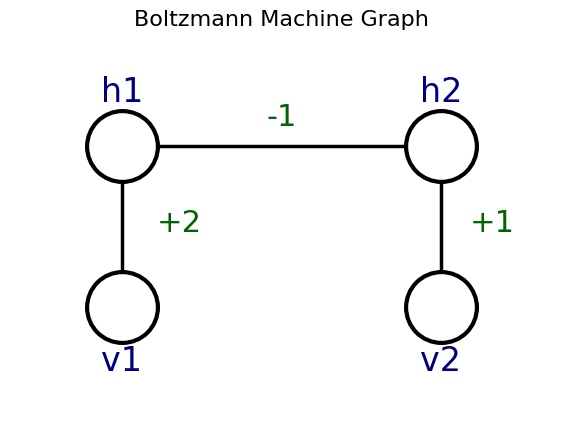

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an undirected graph
G = nx.Graph()

# Add nodes
G.add_node("h1")
G.add_node("h2")
G.add_node("v1")
G.add_node("v2")

# Add weighted edges from the diagram
G.add_edge("h1", "h2", weight=w_h1_h2)
G.add_edge("v1", "h1", weight=w_v1_h1)
G.add_edge("v2", "h2", weight=w_v2_h2)

# Position nodes to mirror the uploaded image
pos = {
    "h1": (0, 1),
    "h2": (2, 1),
    "v1": (0, 0),
    "v2": (2, 0),
}

plt.figure(figsize=(7, 5))

# Draw edges first
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[("h1", "h2"), ("v1", "h1"), ("v2", "h2")],
    width=2.5,
    edge_color="black"
)

# Draw nodes as large open circles
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2600,
    node_color="white",
    edgecolors="black",
    linewidths=3
)

# Node labels, placed similar to the image
label_pos = {
    "h1": (0, 1.34),
    "h2": (2, 1.34),
    "v1": (0, -0.34),
    "v2": (2, -0.34),
}

for node, (x, y) in label_pos.items():
    plt.text(
        x,
        y,
        node,
        fontsize=24,
        ha="center",
        va="center",
        color="navy"
    )

# Edge weight labels, placed similar to the image
plt.text(
    1,
    1.18,
    "-1",
    fontsize=22,
    ha="center",
    va="center",
    color="darkgreen"
)

plt.text(
    0.22,
    0.52,
    "+2",
    fontsize=22,
    ha="left",
    va="center",
    color="darkgreen"
)

plt.text(
    2.18,
    0.52,
    "+1",
    fontsize=22,
    ha="left",
    va="center",
    color="darkgreen"
)

plt.title("Boltzmann Machine Graph", fontsize=16)
plt.xlim(-0.7, 2.7)
plt.ylim(-0.7, 1.7)
plt.axis("off")
plt.show()

From this graph, the energy function is built by writing one term per edge:

$$
E(v,h)
=
-\left(
2v_1h_1 + v_2h_2 - h_1h_2
\right)
$$

The positive edges lower energy when connected units are on together. The negative edge raises energy when both connected hidden units are on together.

## Step 3: Define the Score Function

For this example, we use the Boltzmann Machine energy function:

$$
E(v,h) = -\sum_{i,j} w_{ij}x_i x_j
$$

For this network, that becomes:

$$
E(v_1,v_2,h_1,h_2)
=
-\left(
2v_1h_1 + 1v_2h_2 - 1h_1h_2
\right)
$$

The probability formula uses:

$$
e^{-E(v,h)}
$$

Since the energy is negative of the weighted sum, we can define a score:

$$
\text{score}(v_1,v_2,h_1,h_2) = -E(v_1,v_2,h_1,h_2)
$$

So:

$$
\text{score}(v_1,v_2,h_1,h_2)
=
2v_1h_1 + v_2h_2 - h_1h_2
$$

Then:

$$
e^{-E(v,h)} = e^{\text{score}(v,h)}
$$

In [5]:
def score(v1, v2, h1, h2):
    """
    score = -Energy, assuming:

    E = -sum(w_ij * x_i * x_j)

    Therefore:

    score = sum(w_ij * x_i * x_j)
    """
    return (
        w_v1_h1 * v1 * h1
        + w_v2_h2 * v2 * h2
        + w_h1_h2 * h1 * h2
    )

## Step 4: Understand the Probability of a Full State

A full state includes both visible and hidden values:

$$
(v_1, v_2, h_1, h_2)
$$

The unnormalized probability of a full state is:

$$
P^*(v,h) = e^{-E(v,h)}
$$

Using our score function:

$$
P^*(v,h) = e^{\text{score}(v,h)}
$$

For example, if:

$$
v_1 = 1,\quad v_2 = 0,\quad h_1 = 1,\quad h_2 = 0
$$

then:

$$
\text{score} = 2(1)(1) + 1(0)(0) - 1(1)(0)
$$

$$
\text{score} = 2
$$

So:

$$
P^*(1,0,1,0) = e^2
$$

In [6]:
# Example full-state score
example_score = score(v1=1, v2=0, h1=1, h2=0)
example_unnormalized_probability = math.exp(example_score)

print("Example full state: v1=1, v2=0, h1=1, h2=0")
print(f"score = {example_score}")
print(f"exp(score) = {example_unnormalized_probability:.10f}")

Example full state: v1=1, v2=0, h1=1, h2=0
score = 2
exp(score) = 7.3890560989


## Step 5: Sum Over Hidden States for Each Visible Vector

We are interested in the visible vector:

$$
(v_1, v_2)
$$

But the hidden units can take multiple possible values.

For each visible vector, we sum over all possible hidden states:

$$
P^*(v_1,v_2)
=
\sum_{h_1,h_2}
e^{\text{score}(v_1,v_2,h_1,h_2)}
$$

Because there are two binary hidden units, there are four hidden configurations:

$$
(h_1,h_2) \in \{(0,0),(0,1),(1,0),(1,1)\}
$$

So for each visible vector:

$$
P^*(v_1,v_2)
=
e^{\text{score}(v_1,v_2,0,0)}
+
e^{\text{score}(v_1,v_2,0,1)}
+
e^{\text{score}(v_1,v_2,1,0)}
+
e^{\text{score}(v_1,v_2,1,1)}
$$

In [7]:
# Compute unnormalized probability for each visible vector
visible_unnormalized = {}

for v1, v2 in itertools.product(states, states):
    total = 0.0

    # Sum over all hidden states
    for h1, h2 in itertools.product(states, states):
        total += math.exp(score(v1, v2, h1, h2))

    visible_unnormalized[(v1, v2)] = total

## Step 6: Display the Unnormalized Visible Probabilities

The values we have computed so far are not final probabilities yet.

They are unnormalized probabilities:

$$
P^*(v_1,v_2)
$$

They tell us the relative preference for each visible vector, but they do not necessarily sum to 1.

To turn them into probabilities, we need the partition function.

In [8]:
print("Unnormalized visible probabilities:")

for visible, value in visible_unnormalized.items():
    print(f"P*{visible} = {value:.10f}")

Unnormalized visible probabilities:
P*(0, 0) = 3.3678794412
P*(0, 1) = 5.7182818285
P*(1, 0) = 12.1073379274
P*(1, 1) = 18.4963940263


## Step 7: Calculate the Partition Function

The partition function is the sum of all unnormalized probabilities.

For the visible vectors, we can write:

$$
Z =
\sum_{v_1,v_2}
P^*(v_1,v_2)
$$

Equivalently, if we sum over both visible and hidden units:

$$
Z =
\sum_{v_1,v_2,h_1,h_2}
e^{\text{score}(v_1,v_2,h_1,h_2)}
$$

This value normalizes the distribution so that the probabilities sum to 1.

In [9]:
# Partition function Z
Z = sum(visible_unnormalized.values())

print(f"Partition function Z = {Z:.10f}")

Partition function Z = 39.6898932233


## Step 8: Normalize the Visible Probabilities

The final probability of a visible vector is:

$$
P(v_1,v_2)
=
\frac{P^*(v_1,v_2)}{Z}
$$

Substituting the hidden-state sum:

$$
P(v_1,v_2)
=
\frac{
\sum_{h_1,h_2}
e^{\text{score}(v_1,v_2,h_1,h_2)}
}
{
\sum_{v_1,v_2,h_1,h_2}
e^{\text{score}(v_1,v_2,h_1,h_2)}
}
$$

This gives us a valid probability distribution over the visible vectors.

In [10]:
# Normalize
visible_probabilities = {
    visible: value / Z
    for visible, value in visible_unnormalized.items()
}

## Step 9: Print the Final Probabilities

Now we print the normalized probability for each visible vector:

$$
(0,0), (0,1), (1,0), (1,1)
$$

These probabilities should sum to 1.

In [11]:
print("Normalized visible probabilities:")

for visible, prob in visible_probabilities.items():
    print(f"P{visible} = {prob:.10f}")

print()
print(f"Sum of probabilities = {sum(visible_probabilities.values()):.10f}")

Normalized visible probabilities:
P(0, 0) = 0.0848548375
P(0, 1) = 0.1440740038
P(1, 0) = 0.3050483875
P(1, 1) = 0.4660227711

Sum of probabilities = 1.0000000000


## Step 10: Full Output Summary

The most likely visible vector is the one with the largest probability.

In this example, the network favors visible states where the visible units activate hidden units through positive weights.

The connection

$$
w_{v_1h_1} = 2
$$

is stronger than

$$
w_{v_2h_2} = 1
$$

so turning on \(v_1\) tends to have a larger effect than turning on \(v_2\).

However, the hidden units also have a negative connection:

$$
w_{h_1h_2} = -1
$$

which discourages \(h_1\) and \(h_2\) from being on together.

The final visible probabilities reflect the combined effect of all these interactions.

In [12]:
most_likely_visible = max(
    visible_probabilities,
    key=visible_probabilities.get
)

print(f"Most likely visible vector: {most_likely_visible}")
print(f"Probability: {visible_probabilities[most_likely_visible]:.10f}")

Most likely visible vector: (1, 1)
Probability: 0.4660227711


## Optional Debugging Table: Hidden-State Contributions

The key calculation in a Boltzmann Machine is the sum over hidden states.

For each visible vector:

$$
(v_1, v_2)
$$

we calculate the contribution from each hidden vector:

$$
(h_1, h_2)
$$

using:

$$
\text{score}(v_1,v_2,h_1,h_2)
=
2v_1h_1 + v_2h_2 - h_1h_2
$$

and:

$$
e^{\text{score}(v_1,v_2,h_1,h_2)}
$$

Then we add those four hidden-state contributions to get:

$$
P^*(v_1,v_2)
=
\sum_{h_1,h_2}
e^{\text{score}(v_1,v_2,h_1,h_2)}
$$

The table below shows exactly where each unnormalized visible probability comes from.



In [13]:
# Build a detailed table showing each hidden-state contribution
rows = []

for v1, v2 in itertools.product(states, states):
    for h1, h2 in itertools.product(states, states):
        s = score(v1, v2, h1, h2)
        contribution = math.exp(s)

        rows.append({
            "v1": v1,
            "v2": v2,
            "h1": h1,
            "h2": h2,
            "score": s,
            "exp(score)": contribution,
            "visible vector": (v1, v2)
        })

# Display as a pandas DataFrame
import pandas as pd

df = pd.DataFrame(rows)

df

,v1,v2,h1,h2,score,exp(score),visible vector
0,0,0,0,0,0,1.000000,"(0, 0)"
1,0,0,0,1,0,1.000000,"(0, 0)"
2,0,0,1,0,0,1.000000,"(0, 0)"
3,0,0,1,1,-1,0.367879,"(0, 0)"
4,0,1,0,0,0,1.000000,"(0, 1)"
5,0,1,0,1,1,2.718282,"(0, 1)"
6,0,1,1,0,0,1.000000,"(0, 1)"
7,0,1,1,1,0,1.000000,"(0, 1)"
8,1,0,0,0,0,1.000000,"(1, 0)"
9,1,0,0,1,0,1.000000,"(1, 0)"


## Summing the Contributions by Visible Vector

Now we group the table by visible vector and sum the hidden-state contributions.

This should match the earlier unnormalized values:

$$
P^*(v_1,v_2)
$$

In [14]:
summary_df = (
    df.groupby("visible vector")["exp(score)"]
    .sum()
    .reset_index()
    .rename(columns={"exp(score)": "P*(visible)"})
)

summary_df["P(visible)"] = summary_df["P*(visible)"] / Z

summary_df

,visible vector,P*(visible),P(visible)
0,"(0, 0)",3.367879,0.084855
1,"(0, 1)",5.718282,0.144074
2,"(1, 0)",12.107338,0.305048
3,"(1, 1)",18.496394,0.466023


This final table shows both:

$$
P^*(v_1,v_2)
$$

the unnormalized value, and:

$$
P(v_1,v_2)
=
\frac{P^*(v_1,v_2)}{Z}
$$

the normalized probability.